In [1]:
import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
import json

print("All modules imported")

All modules imported


1234
1083
1061


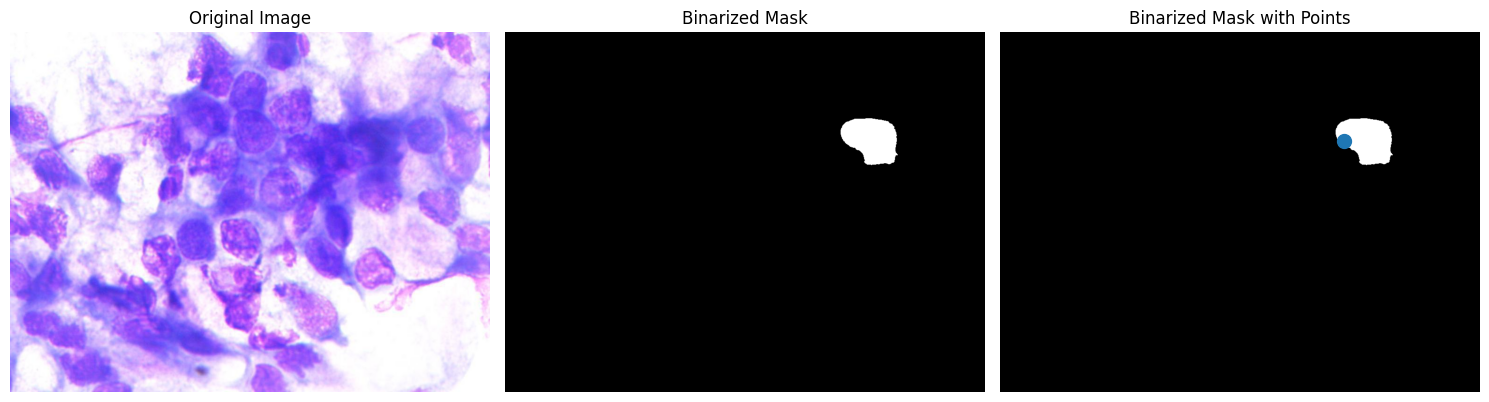

In [2]:
import os
import json
import numpy as np

train_data_dir = r"C:\Users\Admin\Desktop\NC_Project\Random_Train_51"
train_images_dir = os.path.join(train_data_dir, "images")
train_masks_dir = os.path.join(train_data_dir, "masks")
train_json_dir =os.path.join(train_data_dir,"labels.json")

with open(train_json_dir) as f:
    train_data=json.load(f)

train_all_data = []
train_all_images=[]
for entry in train_data['images']:
    image_name = entry['image_name']
    masks = [label['mask_file'] for label in entry['labels']]
    
    train_all_images.append({
        "image": os.path.join(train_images_dir, image_name),
        "masks": [os.path.join(train_masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

train_final_data = []
for entry in train_all_images:
    for mask in entry['masks']:
        train_final_data.append({
            "image": entry["image"],
            "annotation": mask
        })
print(len(train_final_data))
####################################################################

vt_data_dir=r"C:\Users\Admin\Desktop\New_Dataset"
vt_images_dir= os.path.join(vt_data_dir,"images")
vt_masks_dir=os.path.join(vt_data_dir,"masks")
vt_json_dir=os.path.join(vt_data_dir,"labels.json")

with open(vt_json_dir) as f:
    vt_data=json.load(f)

vt_all_data=[]
vt_all_images=[]
for entry in vt_data['images']:
    image_name=entry['image_name']
    masks=[label['mask_file'] for label in entry['labels']]

    vt_all_images.append({
        "image":os.path.join(vt_images_dir, image_name),
        "masks": [os.path.join(vt_masks_dir, mask) for mask in masks],
        "labels":[label['label'] for label in entry['labels']]
    })
vt_final_data=[]
for entry in vt_all_images:
    for mask in entry['masks']:
        vt_final_data.append({
            "image": entry["image"],
            "annotation":mask
        })
print(len(vt_final_data))
###################################################################

test_data_dir = r"C:\Users\Admin\Desktop\New_Test_Dataset"
test_images_dir = os.path.join(test_data_dir, "images")
test_masks_dir = os.path.join(test_data_dir, "masks")
test_json_dir =os.path.join(test_data_dir,"labels.json")

with open(test_json_dir) as f:
    test_data=json.load(f)

test_all_data = []
test_all_images=[]
for entry in test_data['images']:
    image_name = entry['image_name']
    masks = [label['mask_file'] for label in entry['labels']]
    
    test_all_images.append({
        "image": os.path.join(test_images_dir, image_name),
        "masks": [os.path.join(test_masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

test_final_data = []
for entry in test_all_images:
    for mask in entry['masks']:
        test_final_data.append({
            "image": entry["image"],
            "annotation": mask
        })
print(len(test_final_data))

def read_batch(data, visualize_data=False):
    # Select a random entry
    ent = data[np.random.randint(len(data))]

    # Get full paths
    Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
    ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

    if Img is None or ann_map is None:
        print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotation']}")
        return None, None, None, 0

    # Resize image and mask
    r = np.min([1024 / Img.shape[1], 1024 / Img.shape[0]])  # Scaling factor
    Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
    ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
    points=[]
    inds = np.unique(ann_map)[1:]
    for ind in inds:
        mask = (ann_map == ind).astype(np.uint8)
        binary_mask = np.maximum(binary_mask, mask)
    coords = np.argwhere(binary_mask > 0)
    if len(coords) > 0:
        for _ in inds:
            yx = np.array(coords[np.random.randint(len(coords))])
            points.append([yx[1], yx[0]])
    points = np.array(points)

    if visualize_data:
        # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')
        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()
        
    binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
    binary_mask = binary_mask.transpose((2, 0, 1))
    points = np.expand_dims(points, axis=1)

    # Return the image, binarized mask, points, and number of masks
    return Img, binary_mask, points, len(inds)

Img1, masks1, points1, num_masks = read_batch(train_final_data, visualize_data=True)


In [3]:
def read_image(image_path, mask_path):  # read and resize image and mask
    img = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
    mask = cv2.imread(mask_path, 0)
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
    img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r)))
    mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    return img, mask

def get_points(mask, num_points):  # Sample points inside the input mask
    points = []
    coords = np.argwhere(mask > 0)
    for i in range(num_points):
        yx = np.array(coords[np.random.randint(len(coords))])
        points.append([[yx[1], yx[0]]])
    return np.array(points)

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random
from PIL import Image
from torchvision import transforms

train_all_data=[]
for entry in train_data['images']:
    image_name = entry['image_name']
    image_path = os.path.join(train_images_dir, image_name)

    image = Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path = os.path.join(train_masks_dir, label_info['mask_file'])
        label = label_info['label']
        mask = Image.open(mask_path).convert("L")
        masked_image = Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image = np.array(masked_image)
        train_all_data.append({"masked_image": masked_image, "label": label})
#################################################################################
val_test_data=[]
for entry in vt_data['images']:
    image_name=entry['image_name']
    image_path=os.path.join(vt_images_dir, image_name)
    image=Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path=os.path.join(vt_masks_dir, label_info['mask_file'])
        label=label_info['label']
        mask=Image.open(mask_path).convert("L")
        masked_image=Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image=np.array(masked_image)
        val_test_data.append({'masked_image':masked_image, 'label': label})
#################################################################################
test_all_data=[]
for entry in test_data['images']:
    image_name= entry['image_name']
    image_path= os.path.join(test_images_dir, image_name)

    image=Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path=os.path.join(test_masks_dir, label_info['mask_file'])
        label=label_info['label']

        mask=Image.open(mask_path).convert("L")

        masked_image = Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image = np.array(masked_image)

        test_all_data.append({"masked_image":masked_image, "label":label})
        
#label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
#                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
#                 "mast cell": 9, "lymphocyte": 10}


copies_per_class={"epithelial":1,
                  "neutrophil": 1,
                  "artefatto": 5,
                  "muciparous":10,
                  "eosinophil":10,
                  "metaplastic": 10,
                  "epithelial ciliated": 10,
                  "lymphocyte": 10,
                  "mast cell": 10,
                  "emazia" : 10
                 }

class MaskedImageDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None, augmentations=None, copies_per_class=None):

        self.data = data
        self.transform = transform
        self.augmentations = augmentations
        self.copies_per_class = copies_per_class or {}
        self.expanded_data = self._expand_data()
    
    def _expand_data(self):
        expanded_data = []
        for item in self.data:
            label = item["label"]
            num_copies = self.copies_per_class.get(label, 1)
            expanded_data.append(item)
            
            for _ in range(num_copies - 1):
                augmented_item = item.copy()
                image = item["masked_image"]
                
                if not isinstance(image, np.ndarray):
                    image = np.array(image)

                if self.augmentations:
                    augmented_data = self.augmentations(image=image)
                    augmented_item["masked_image"] = augmented_data["image"]

                expanded_data.append(augmented_item)

        return expanded_data

    def __getitem__(self, idx):
        item = self.expanded_data[idx]
        masked_image = item["masked_image"]
        label = item["label"]

        masked_image=np.array(masked_image)
        image_pil = Image.fromarray(masked_image)
        image_resized = image_pil.resize((224, 224))
        masked_image = np.array(image_resized)
        #if self.augmentations and isinstance(masked_image, np.ndarray):
            #masked_image = np.array(masked_image)

        #if self.augmentations:
        #    augmented = self.augmentations(image=masked_image)
        #    masked_image = augmented["image"]

        masked_image = torch.tensor(masked_image, dtype=torch.float32)
    
        
        #if self.transform:
            #masked_image = self.transform(masked_image)
                
        return masked_image, label

    def __len__(self):
        return len(self.expanded_data)


albumentations_augmentations = A.Compose([
    A.RandomBrightnessContrast(p=1.0),
    A.VerticalFlip(p=0.5)
])

torchvision_transform = transforms.Compose([
    transforms.Resize((224,224))
])

train_dataset = MaskedImageDataset(
    train_all_data,
    augmentations=albumentations_augmentations,
    copies_per_class=copies_per_class,
    transform=torchvision_transform
)

#train_dataset = MaskedImageDataset(
#    train_all_data,
#    #val_test_data,
#    transform=torchvision_transform, 
#    augmentations=albumentations_augmentations, 
#    num_copies=4
#)

final_test_dataset= MaskedImageDataset(
    test_all_data,
    transform=torchvision_transform
)

test_dataset=MaskedImageDataset(
    val_test_data,
    #train_all_data,
    transform=torchvision_transform
)

final_test_loader=torch.utils.data.DataLoader(final_test_dataset, batch_size=4, shuffle=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)

C:\Users\Admin\anaconda3\envs\NC_Torch\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.3 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [5]:
len(train_all_data)

1234

torch.Size([224, 224, 3])


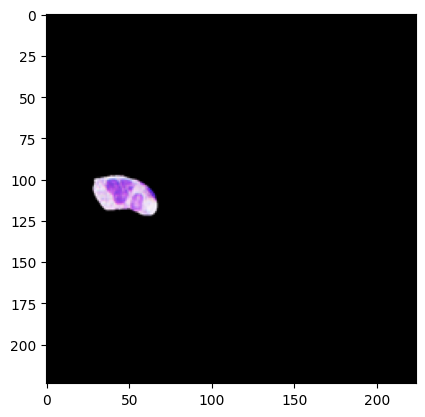

In [6]:
import cv2
data_iter = iter(train_loader)
images, labels = next(data_iter)

image = images[2]
label = labels[2]
print(image.shape) 

image=image.numpy()

image_np = (image * 1).astype(np.uint8)

plt.imshow(image_np)
plt.show()

In [7]:
from torchvision.models import resnet50, ResNet50_Weights
classifier = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
#print(classifier)

In [8]:
#import torch.nn as nn
#new_classifier = nn.Sequential(
#    nn.Linear(classifier.last_linear.in_features, 512),
#    nn.ReLU(),
#    nn.Dropout(0.1),
#    nn.Linear(512, 256),
#    nn.ReLU(),
#    nn.Dropout(0.1),
#    nn.Linear(256, 10)
#)
#classifier.last_linear=new_classifier
#print(classifier)

In [9]:
child_counter = 0
for child in classifier.children():
   #print(" child", child_counter, "is:")
   #print(child)
   child_counter += 1

In [10]:
import torch.nn as nn
def freeze_children(model, n):
    num_frozen = 0
    for name, param in model.named_parameters():
        if num_frozen < n:
            param.requires_grad = False
            num_frozen += 1
        else:
            break
    
freeze_children(classifier,0)
count=0
for name, param in classifier.named_parameters():
  #print(f"Layer: {name}, requires_grad: {param.requires_grad}")
  count+=1

print(count)

161



=== Fold 1/4 ===


C:\Users\Admin\anaconda3\envs\NC_Torch\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 1 Epoch [1/30] - Loss: 1.2878, Training Accuracy: 14.60%
Epoch validation accuracy: 28.488
Epoch's tentative final test accuracy:  46.277


Fold 1 Epoch [2/30] - Loss: 0.4520, Training Accuracy: 44.10%
Epoch validation accuracy: 45.374
Epoch's tentative final test accuracy:  51.367


Fold 1 Epoch [3/30] - Loss: 0.3272, Training Accuracy: 56.54%
Epoch validation accuracy: 51.248
Epoch's tentative final test accuracy:  55.608


...

Fold 4 Epoch [26/30] - Loss: 0.0254, Training Accuracy: 97.36%
Epoch validation accuracy: 87.794
Epoch's tentative final test accuracy:  65.221


Fold 4 Epoch [27/30] - Loss: 0.0203, Training Accuracy: 97.94%
Epoch validation accuracy: 90.000
Epoch's tentative final test accuracy:  64.373


Fold 4 Epoch [28/30] - Loss: 0.0168, Training Accuracy: 98.14%
Epoch validation accuracy: 89.559
Epoch's tentative final test accuracy:  65.787


Fold 4 Epoch [29/30] - Loss: 0.0168, Training Accuracy: 97.94%
Epoch validation accuracy: 87.794
Epoch's tentative final test accuracy:  66.635


Fold 4 Epoch [30/30] - Loss: 0.0158, Training Accuracy: 98.14%
Epoch validation accuracy: 90.735
Epoch's tentative final test accuracy:  65.504
Fold 4 Validation Accuracy: 90.74%, Test Accuracy: 60.76%

=== Cross-Validation Results ===
Average Validation Accuracy: 87.84%
Average Test Accuracy: 61.31%


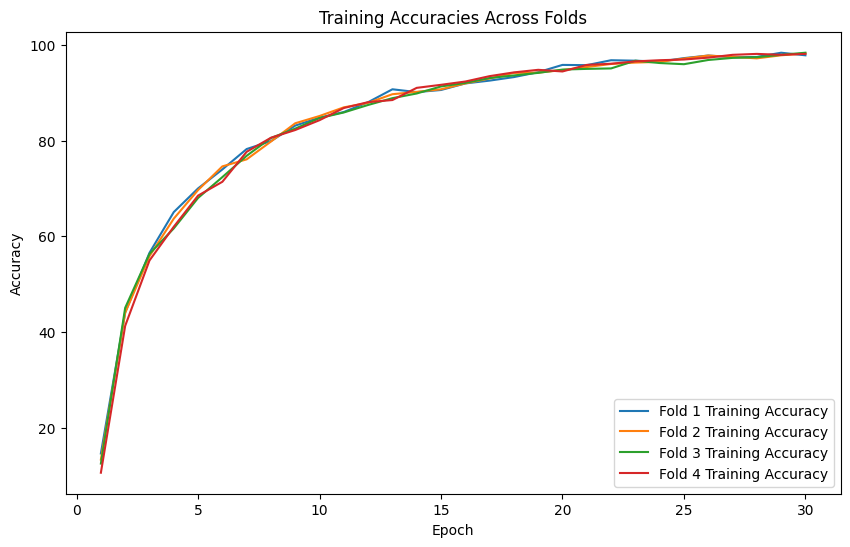

In [11]:
from torch.optim import SGD, Adam
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

k=4
batch_size=4
fold_train_accuracies = []
fold_val_accuracies = []
fold_t_accuracies = []
fold_test_accuracies=[]
dataset = train_dataset

kf = KFold(n_splits=k, shuffle=True, random_state=42)

num_classes = 10
#classifier = timm.create_model('inception_v4', pretrained=True, num_classes=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.00005)
num_epochs = 30

label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}

train_accuracies, test_accuracies, train_losses = [], [], []
checkpoint_dir = r"C:\Users\Admin\Documents\resnet50_Checks"

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    best_fva=0
    print(f"\n=== Fold {fold+1}/{k} ===")

    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset = torch.utils.data.Subset(dataset, val_idx)
    train_loader_kfold = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader_kfold = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Reinitializing model, optimizer, scheduler and criterion for each fold
    classifier = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    #classifier.last_linear = new_classifier
    #print(classifier)
    #freeze_children(classifier, 0)
    classifier.to(torch.float32)
    classifier.to(device)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(classifier.parameters(), lr=1*1e-5)

    
    # Training Loop
    fold_train_accuracy = []
    fold_val_accuracy = []
    fold_t_accuracy=[]
    for epoch in range(num_epochs):
        classifier.train()
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        total_val_loss=0.0
        total_t_loss=0.0
        progress_bar = tqdm(train_loader_kfold, desc=f"Fold {fold+1} Epoch {epoch+1}/{num_epochs}", leave=False)
        
        # Processing one epoch within each fold
        for masked_images, labels in progress_bar:
            masked_images = masked_images.permute(0, 3, 1, 2)
            masked_images = masked_images.to(torch.float32).to(device)
            optimizer.zero_grad()

            outputs = classifier(masked_images)
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            loss = criterion(outputs, numeric_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == numeric_labels).sum().item()
            total_predictions += len(numeric_labels)

            avg_loss = running_loss / total_predictions
            accuracy = correct_predictions / total_predictions * 100
            progress_bar.set_postfix(loss=avg_loss, accuracy=f"{accuracy:.2f}%")
            
        # Printing epoch metrics
        print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Training Accuracy: {accuracy:.2f}%")
        fold_train_accuracy.append(accuracy)  # Appending accuracy of each epoch to one list
        
        # Getting validation results for the epoch
        classifier.eval()
        correct_val_predictions, total_val_predictions = 0, 0
        correct_t_predictions, total_t_predictions=0,0
        with torch.no_grad():
            for masked_images, labels in val_loader_kfold:
                masked_images = masked_images.permute(0, 3, 1, 2)
                masked_images = masked_images.to(device)
                outputs = classifier(masked_images)
                #print("validation outputs: ")
                #print(outputs)
                numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
                _, predicted = torch.max(outputs, 1)
                correct_val_predictions += (predicted == numeric_labels).sum().item()
                total_val_predictions += len(numeric_labels)
                loss = criterion(outputs, numeric_labels)
                total_val_loss += loss.item()

            for masked_images, labels in final_test_loader:
                masked_images=masked_images.permute(0,3,1,2)
                masked_images=masked_images.to(device)
                outputs=classifier(masked_images)
                numeric_labels=torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
                _, predicted=torch.max(outputs,1)
                correct_t_predictions+=(predicted == numeric_labels).sum().item()
                total_t_predictions+=len(numeric_labels)
                loss=criterion(outputs, numeric_labels)
                total_t_loss+=loss.item()

        average_val_loss = total_val_loss / len(val_loader_kfold)
        val_accuracy = correct_val_predictions / total_val_predictions * 100
        print(f"Epoch validation accuracy: {val_accuracy:.3f}")

        average_t_loss=total_t_loss/len(final_test_loader)
        scheduler.step(average_val_loss) # Implementing Reduce LR On Plateau here
        t_accuracy= correct_t_predictions/total_t_predictions * 100
        print(f"Epoch's tentative final test accuracy: {t_accuracy: .3f}")
        
        fold_val_accuracy.append(val_accuracy) # Appending epoch validation accuracy to one list
        fold_t_accuracy.append(t_accuracy)
        if val_accuracy>best_fva:
            best_fva=t_accuracy
            checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_fold{fold+1}_{t_accuracy:.3f}.pth") # Saving
            torch.save(classifier.state_dict(), checkpoint_path)
            
    # Appending the list of all epoch accuracies in a fold to another list of fold accuracies
    fold_train_accuracies.append(fold_train_accuracy)
    fold_val_accuracies.append(fold_val_accuracy)
    # Evaluation on test_loader, once per each fold
    correct_test_predictions, total_test_predictions = 0, 0
    classifier.eval()
    with torch.no_grad():
        for masked_images, labels in test_loader:
            masked_images=masked_images.permute(0,3,1,2)
            masked_images = masked_images.to(device)
            outputs = classifier(masked_images)
            #outputs= outputs.logits
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            _, predicted = torch.max(outputs, 1)
            correct_test_predictions += (predicted == numeric_labels).sum().item()
            total_test_predictions += len(numeric_labels)

    test_accuracy = correct_test_predictions / total_test_predictions * 100
    fold_test_accuracies.append(test_accuracy)
    # checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_TA_{test_accuracy}_FVA_{fold_val_accuracy[-1]}.pth")
    # Printing the fold's best validation and test accuracy
    print(f"Fold {fold+1} Validation Accuracy: {fold_val_accuracy[-1]:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

# Cross-Validation Summary
print("\n=== Cross-Validation Results ===")
avg_val_accuracy = sum([acc[-1] for acc in fold_val_accuracies]) / k
avg_test_accuracy = sum(fold_test_accuracies) / k
print(f"Average Validation Accuracy: {avg_val_accuracy:.2f}%")
print(f"Average Test Accuracy: {avg_test_accuracy:.2f}%")

plt.figure(figsize=(10, 6))
for fold_idx, train_acc in enumerate(fold_train_accuracies):
    plt.plot(range(1, num_epochs + 1), train_acc, label=f"Fold {fold_idx + 1} Training Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracies Across Folds')
plt.show()

In [ ]:
print("Fold Test Accuracies: ", fold_test_accuracies)

In [14]:
#FOLD 1
label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}
label_mapping_reversed={
    1:"epithelial",
    2:"muciparous",
    3:"artefatto",
    4:"neutrophil",
    5:"epithelial ciliated",
    6:"emazia",
    7:"metaplastic",
    8:"eosinophil",
    9:"mast cell",
    10:"lymphocyte"
}
num_classes=10
correct_per_class = [0] * num_classes
total_per_class = [0] * num_classes

model=resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# model.fc = new_classifier
checkpoint_path=r"C:\Users\Admin\Documents\resnet50_Checks\classifier_epoch_30_fold1_65.787.pth"


model.load_state_dict(torch.load(checkpoint_path))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
correct = 0
total = 0

with torch.no_grad():
    for masked_images, labels in final_test_loader:
        masked_images = masked_images.permute(0, 3, 1, 2)
        masked_images = masked_images.to(device)
        outputs = model(masked_images)
        numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels], dtype=torch.long, device=device)
        
        _, predicted = torch.max(outputs, 1)

        total += len(numeric_labels)
        correct += (predicted==numeric_labels).sum().item()
        
        for i in range(len(numeric_labels)):
            true_label = numeric_labels[i].item()
            pred_label = predicted[i].item()
            total_per_class[true_label] += 1
            if true_label == pred_label:
                correct_per_class[true_label] += 1

# Calculate accuracy per class
accuracy_per_class = [correct / total if total > 0 else 0 for correct, total in zip(correct_per_class, total_per_class)]
accuracy= 100*(correct/total)
for i, acc in enumerate(accuracy_per_class):
    acc=acc*100
    print(f'Accuracy for class {label_mapping_reversed[i+1]}: {acc:.3f}')

print(accuracy)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18588\2306376572.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


Accuracy for class epithelial: 81.325
Accuracy for class muciparous: 46.809
Accuracy for class artefatto: 25.253
Accuracy for class neutrophil: 73.248
Accuracy for class epithelial ciliated: 36.364
Accuracy for class emazia: 0.000
Accuracy for class metaplastic: 4.762
Accuracy for class eosinophil: 24.528
Accuracy for class mast cell: 0.000
Accuracy for class lymphocyte: 0.000
65.97549481621112


In [15]:
#FOLD 2
label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}
label_mapping_reversed={
    1:"epithelial",
    2:"muciparous",
    3:"artefatto",
    4:"neutrophil",
    5:"epithelial ciliated",
    6:"emazia",
    7:"metaplastic",
    8:"eosinophil",
    9:"mast cell",
    10:"lymphocyte"
}
num_classes=10
correct_per_class = [0] * num_classes
total_per_class = [0] * num_classes

model=resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# model.fc = new_classifier
checkpoint_path=r"C:\Users\Admin\Documents\resnet50_Checks\classifier_epoch_30_fold2_63.996.pth"


model.load_state_dict(torch.load(checkpoint_path))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
correct = 0
total = 0

with torch.no_grad():
    for masked_images, labels in final_test_loader:
        masked_images = masked_images.permute(0, 3, 1, 2)
        masked_images = masked_images.to(device)
        outputs = model(masked_images)
        numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels], dtype=torch.long, device=device)
        
        _, predicted = torch.max(outputs, 1)

        total += len(numeric_labels)
        correct += (predicted==numeric_labels).sum().item()
        
        for i in range(len(numeric_labels)):
            true_label = numeric_labels[i].item()
            pred_label = predicted[i].item()
            total_per_class[true_label] += 1
            if true_label == pred_label:
                correct_per_class[true_label] += 1

# Calculate accuracy per class
accuracy_per_class = [correct / total if total > 0 else 0 for correct, total in zip(correct_per_class, total_per_class)]
accuracy= 100*(correct/total)
for i, acc in enumerate(accuracy_per_class):
    acc=acc*100
    print(f'Accuracy for class {label_mapping_reversed[i+1]}: {acc:.3f}')

print(accuracy)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18588\3309592187.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


Accuracy for class epithelial: 77.510
Accuracy for class muciparous: 51.064
Accuracy for class artefatto: 21.212
Accuracy for class neutrophil: 77.070
Accuracy for class epithelial ciliated: 45.455
Accuracy for class emazia: 0.000
Accuracy for class metaplastic: 4.762
Accuracy for class eosinophil: 22.642
Accuracy for class mast cell: 0.000
Accuracy for class lymphocyte: 0.000
65.1272384542884


In [16]:
#FOLD 3
label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}
label_mapping_reversed={
    1:"epithelial",
    2:"muciparous",
    3:"artefatto",
    4:"neutrophil",
    5:"epithelial ciliated",
    6:"emazia",
    7:"metaplastic",
    8:"eosinophil",
    9:"mast cell",
    10:"lymphocyte"
}
num_classes=10
correct_per_class = [0] * num_classes
total_per_class = [0] * num_classes

model=resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# model.fc = new_classifier
checkpoint_path=r"C:\Users\Admin\Documents\resnet50_Checks\classifier_epoch_30_fold3_65.598.pth"


model.load_state_dict(torch.load(checkpoint_path))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
correct = 0
total = 0

with torch.no_grad():
    for masked_images, labels in final_test_loader:
        masked_images = masked_images.permute(0, 3, 1, 2)
        masked_images = masked_images.to(device)
        outputs = model(masked_images)
        numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels], dtype=torch.long, device=device)
        
        _, predicted = torch.max(outputs, 1)

        total += len(numeric_labels)
        correct += (predicted==numeric_labels).sum().item()
        
        for i in range(len(numeric_labels)):
            true_label = numeric_labels[i].item()
            pred_label = predicted[i].item()
            total_per_class[true_label] += 1
            if true_label == pred_label:
                correct_per_class[true_label] += 1

# Calculate accuracy per class
accuracy_per_class = [correct / total if total > 0 else 0 for correct, total in zip(correct_per_class, total_per_class)]
accuracy= 100*(correct/total)
for i, acc in enumerate(accuracy_per_class):
    acc=acc*100
    print(f'Accuracy for class {label_mapping_reversed[i+1]}: {acc:.3f}')

print(accuracy)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18588\3123573739.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


Accuracy for class epithelial: 83.936
Accuracy for class muciparous: 34.043
Accuracy for class artefatto: 20.202
Accuracy for class neutrophil: 74.841
Accuracy for class epithelial ciliated: 36.364
Accuracy for class emazia: 50.000
Accuracy for class metaplastic: 9.524
Accuracy for class eosinophil: 35.849
Accuracy for class mast cell: 0.000
Accuracy for class lymphocyte: 0.000
67.48350612629595


In [17]:
#FOLD 4
label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}
label_mapping_reversed={
    1:"epithelial",
    2:"muciparous",
    3:"artefatto",
    4:"neutrophil",
    5:"epithelial ciliated",
    6:"emazia",
    7:"metaplastic",
    8:"eosinophil",
    9:"mast cell",
    10:"lymphocyte"
}
num_classes=10
correct_per_class = [0] * num_classes
total_per_class = [0] * num_classes

model=resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# model.fc = new_classifier
checkpoint_path=r"C:\Users\Admin\Documents\resnet50_Checks\classifier_epoch_30_fold4_65.504.pth"


model.load_state_dict(torch.load(checkpoint_path))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
correct = 0
total = 0

with torch.no_grad():
    for masked_images, labels in final_test_loader:
        masked_images = masked_images.permute(0, 3, 1, 2)
        masked_images = masked_images.to(device)
        outputs = model(masked_images)
        numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels], dtype=torch.long, device=device)
        
        _, predicted = torch.max(outputs, 1)

        total += len(numeric_labels)
        correct += (predicted==numeric_labels).sum().item()
        
        for i in range(len(numeric_labels)):
            true_label = numeric_labels[i].item()
            pred_label = predicted[i].item()
            total_per_class[true_label] += 1
            if true_label == pred_label:
                correct_per_class[true_label] += 1

# Calculate accuracy per class
accuracy_per_class = [correct / total if total > 0 else 0 for correct, total in zip(correct_per_class, total_per_class)]
accuracy= 100*(correct/total)
for i, acc in enumerate(accuracy_per_class):
    acc=acc*100
    print(f'Accuracy for class {label_mapping_reversed[i+1]}: {acc:.3f}')

print(accuracy)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18588\1886098460.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


Accuracy for class epithelial: 71.285
Accuracy for class muciparous: 36.170
Accuracy for class artefatto: 8.081
Accuracy for class neutrophil: 87.261
Accuracy for class epithelial ciliated: 45.455
Accuracy for class emazia: 0.000
Accuracy for class metaplastic: 4.762
Accuracy for class eosinophil: 18.868
Accuracy for class mast cell: 0.000
Accuracy for class lymphocyte: 0.000
63.14797360980208
